In [1]:
from biological_age.data.load_data import load_processed_dataset
from biological_age.features.build_features import build_features
from biological_age.features.feature_selection import select_features
from biological_age.split.train_test_split import create_train_test_split


# Load processed dataset
df = load_processed_dataset()


In [2]:
from biological_age.features.build_features import build_features

df_features = build_features(df)

print(df_features.columns)
print(df_features[[
    "blood_urea_nitrogen",
    "creatinine",
    "bun_creatinine_ratio"
]].head())

Index(['sex', 'age_years', 'albumin', 'blood_urea_nitrogen', 'creatinine',
       'uric_acid', 'hba1c_percent', 'total_cholesterol', 'hdl_cholesterol',
       'triglycerides', 'white_blood_cell_count', 'lymphocyte_percent',
       'monocyte_percent', 'neutrophil_percent', 'red_blood_cell_count',
       'hemoglobin', 'hematocrit', 'mean_corpuscular_volume',
       'red_cell_distribution_width', 'platelet_count', 'calcium', 'sodium_si',
       'potassium_si', 'phosphorus', 'total_bilirubin', 'total_protein',
       'globulin', 'ggt_si', 'bun_creatinine_ratio', 'albumin_globulin_ratio',
       'cholesterol_hdl_ratio', 'triglyceride_hdl_ratio'],
      dtype='str')
   blood_urea_nitrogen  creatinine  bun_creatinine_ratio
0                 14.0        0.91             15.384615
1                  NaN         NaN                   NaN
2                 16.0        0.65             24.615385
3                  5.0        0.89              5.617978
4                 12.0        0.50            

In [3]:
X = df.drop(columns=["age_years"])
y = df["age_years"]

In [4]:
df = build_features(df)

In [5]:
engineered_features = [
    "bun_creatinine_ratio",
]

df[engineered_features].describe().T

,count,mean,std,min,25%,50%,75%,max
bun_creatinine_ratio,28256.0,16.301462,5.679911,2.106568,12.328767,15.555556,19.387755,63.333333


In [6]:
df[engineered_features].isna().sum()

bun_creatinine_ratio    8736
dtype: int64

In [7]:
import numpy as np

np.isinf(df[engineered_features]).sum()

bun_creatinine_ratio    0
dtype: int64

In [8]:
X_train, X_test, y_train, y_test = create_train_test_split(X, y,)

In [9]:
from biological_age.preprocessing.preprocess import (
    split_features_target,
)

X, y = split_features_target(df)

print(X.shape)
print(X.columns[-4:])

(36992, 31)
Index(['albumin_globulin_ratio', 'cholesterol_hdl_ratio',
       'triglyceride_hdl_ratio', 'sex'],
      dtype='str')


In [10]:
from biological_age.split.train_test_split import (
    create_train_test_split,
)

X_train, X_test, y_train, y_test = create_train_test_split(
    X,
    y,
)

In [11]:
from biological_age.preprocessing.preprocess import build_preprocessor

preprocessor = build_preprocessor()

In [12]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

xgb_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor,
    ),
    (
        "model",
        XGBRegressor(
            random_state=42,
            n_jobs=-1,
            n_estimators=800,
            max_depth=8,
            learning_rate=0.03,
            subsample=0.7,
            colsample_bytree=1.0,
        ),
    ),
])


In [13]:
xgb_pipeline.fit(
    X_train,
    y_train,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [14]:
y_pred = xgb_pipeline.predict(X_test)

In [15]:
from biological_age.evaluation.evaluate import (
    evaluate_model,
)

metrics = evaluate_model(
    y_test,
    y_pred,
)

metrics

{'mae': 7.562688861703338,
 'rmse': np.float64(10.668864336358236),
 'r2': 0.8012450573180926}

In [16]:
from pathlib import Path
import joblib

model_path = Path("../models/feature_engineered/xgb_pipeline_v2.pkl")
model_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(xgb_pipeline, model_path)

['../models/feature_engineered/xgb_pipeline_v2.pkl']

In [17]:
import json
from pathlib import Path

metrics_v2 = {
    "model": "xgboost",
    "version": "v2",
    "feature_set": "feature_engineered_v1",
    "mae": 7.562688861703338,
    "rmse": 10.668864336358236,
    "r2": 0.8012450573180926,
}

metrics_path = Path("../outputs/metrics/xgb_v2_metrics.json")
metrics_path.parent.mkdir(parents=True, exist_ok=True)

with open(metrics_path, "w") as f:
    json.dump(metrics_v2, f, indent=4)

# Shap for Feature Engineering - Version 2.

In [18]:
import json
import joblib
import numpy as np
import shap
import matplotlib.pyplot as plt
from pathlib import Path

In [19]:
preprocessor = xgb_pipeline.named_steps["preprocessor"]
model = xgb_pipeline.named_steps["model"]

In [20]:
X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

print(X_test_transformed.shape)
print(len(feature_names))
print(feature_names[-4:])

(7399, 31)
31
['numeric__albumin_globulin_ratio' 'numeric__cholesterol_hdl_ratio'
 'numeric__triglyceride_hdl_ratio' 'categorical__sex']


In [21]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

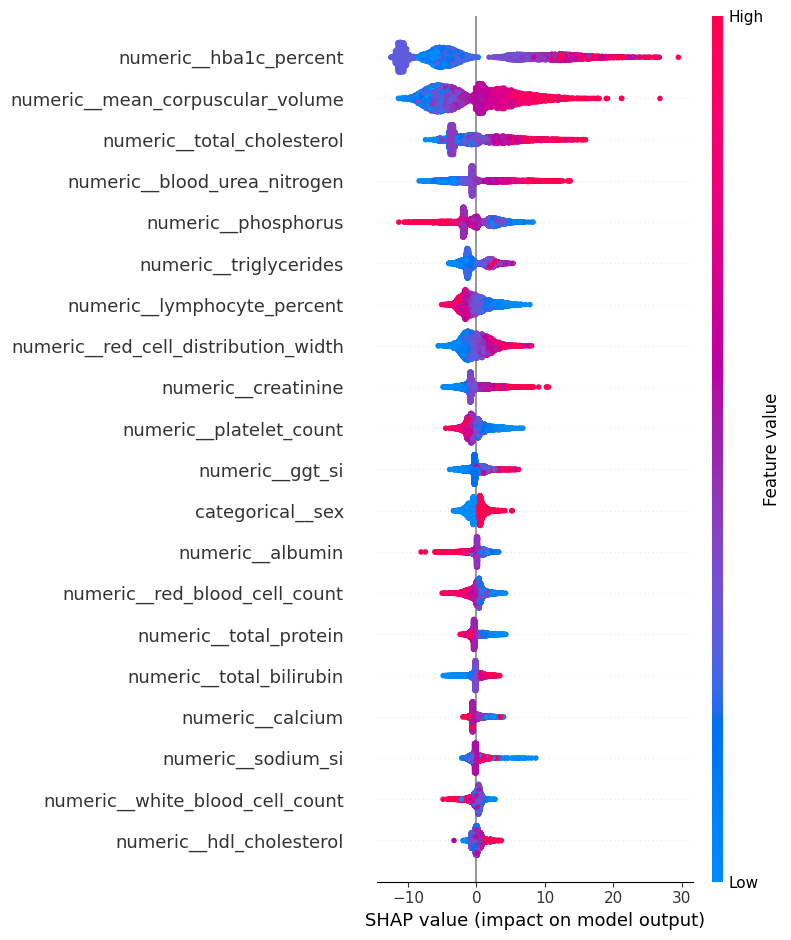

In [22]:
# Beeswarm Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    show=False,
)
plt.tight_layout()
plt.savefig("../outputs/plots/shap_beeswarm_v2.png", dpi=300, bbox_inches="tight")
plt.show()

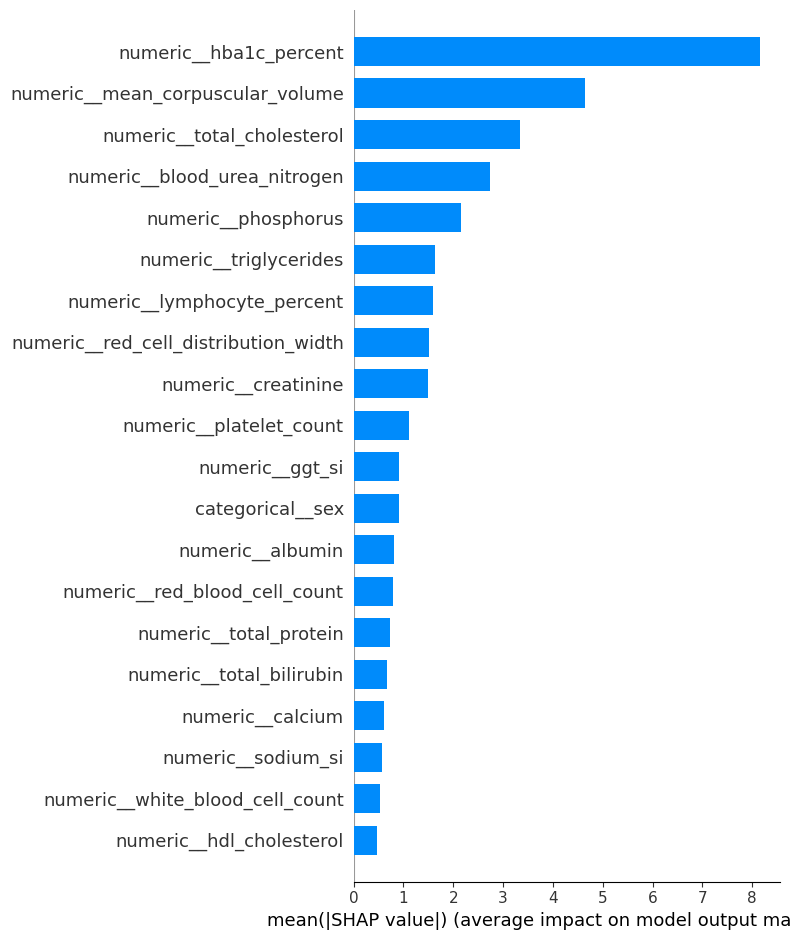

In [23]:
# Bar Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False,
)
plt.tight_layout()
plt.savefig("../outputs/plots/shap_bar_v2.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
#Top 5 dependence plots
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[-5:][::-1]
top_features = [feature_names[i] for i in top_idx]

top_features

['numeric__hba1c_percent',
 'numeric__mean_corpuscular_volume',
 'numeric__total_cholesterol',
 'numeric__blood_urea_nitrogen',
 'numeric__phosphorus']

<Figure size 800x600 with 0 Axes>

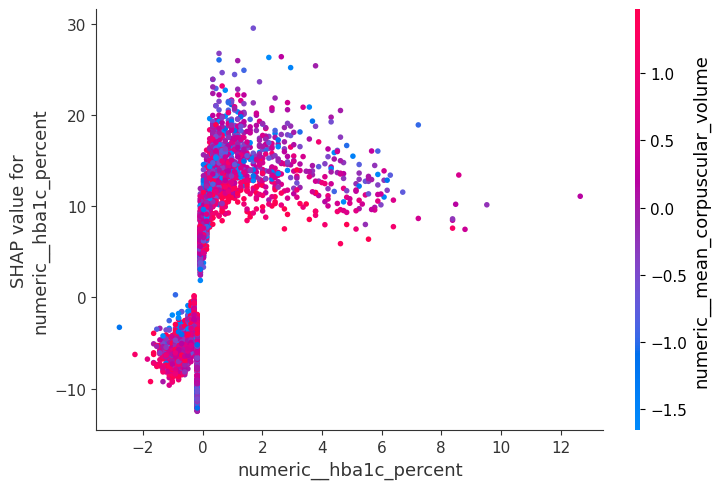

<Figure size 800x600 with 0 Axes>

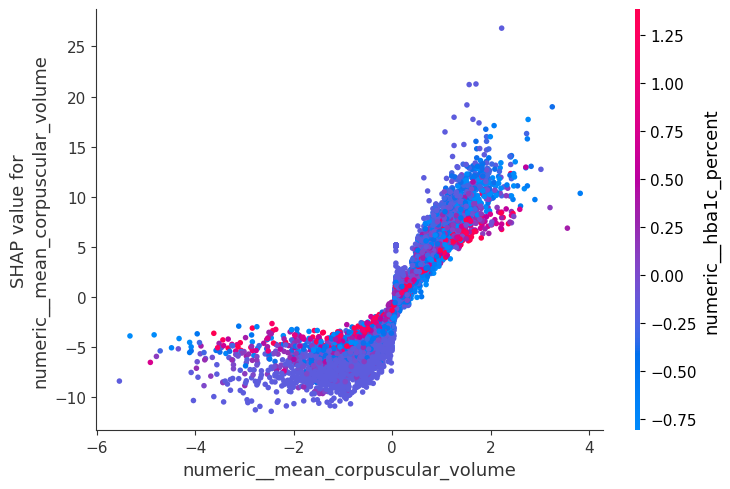

<Figure size 800x600 with 0 Axes>

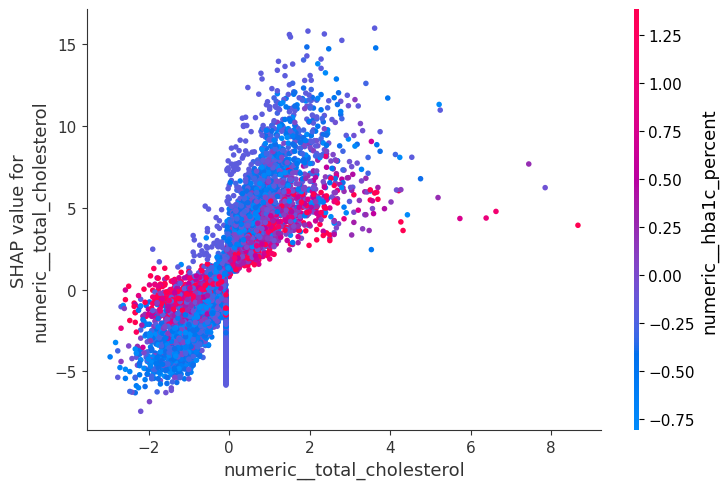

<Figure size 800x600 with 0 Axes>

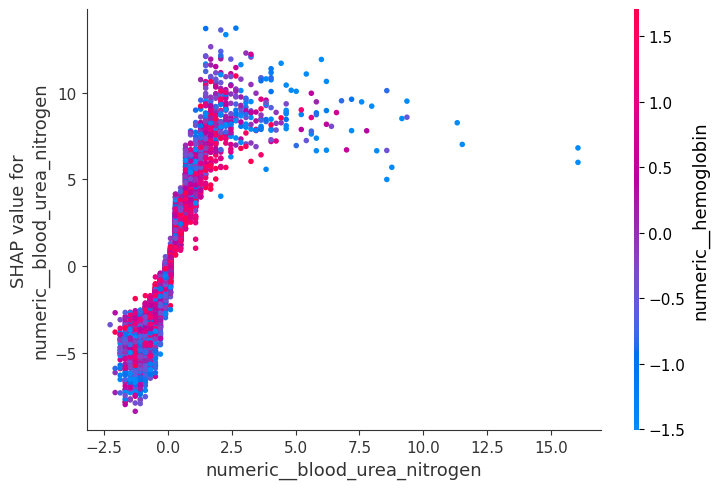

<Figure size 800x600 with 0 Axes>

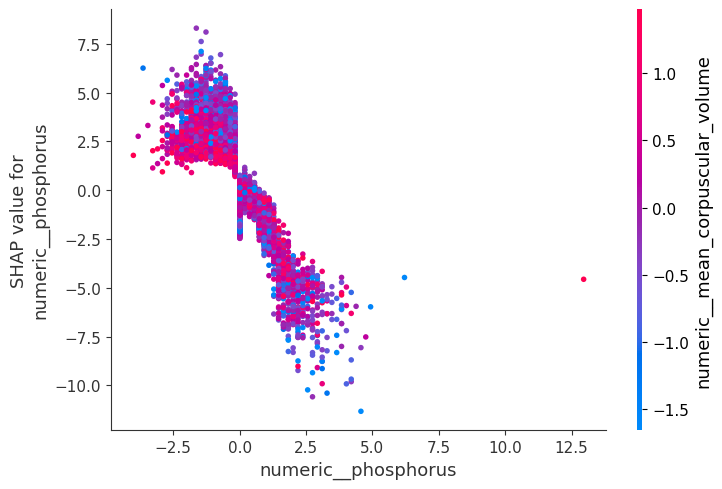

In [25]:
for feat in top_features:
    plt.figure(figsize=(8, 6))
    shap.dependence_plot(
        feat,
        shap_values,
        X_test_transformed,
        feature_names=feature_names,
        interaction_index="auto",
        show=False,
    )
    plt.tight_layout()
    plt.savefig(
        f"../outputs/plots/{feat}_dependence_v2.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

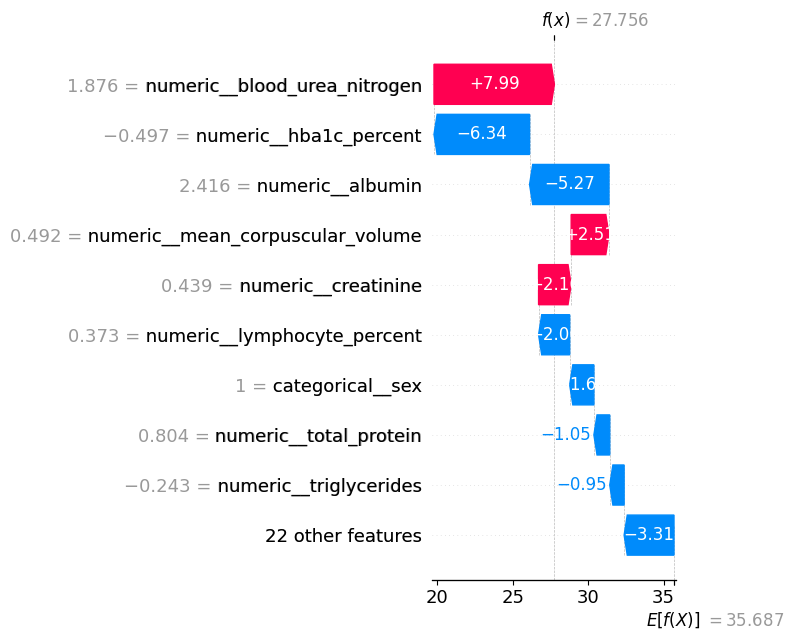

In [26]:
# Waterfall plot for one sample
i = 0

explanation = shap.Explanation(
    values=shap_values[i],
    base_values=explainer.expected_value,
    data=X_test_transformed[i],
    feature_names=feature_names,
)

plt.figure(figsize=(10, 8))
shap.plots.waterfall(explanation, show=False)
plt.tight_layout()
plt.savefig("../outputs/plots/shap_waterfall_v2.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
print(X_test_transformed.shape)
print(len(feature_names))
print(feature_names[-4:])

(7399, 31)
31
['numeric__albumin_globulin_ratio' 'numeric__cholesterol_hdl_ratio'
 'numeric__triglyceride_hdl_ratio' 'categorical__sex']


# Feature Engineering & SHAP Analysis (Version 2)

## Objective

The objective of this phase was to evaluate whether biologically meaningful engineered biomarkers could improve biological age prediction beyond the original laboratory measurements.

Three domain-inspired ratio features were introduced:

- **BUN / Creatinine Ratio** – indicator of kidney function and hydration status.
- **Cholesterol / HDL Ratio** – marker of cardiovascular risk.
- **Triglyceride / HDL Ratio** – proxy for insulin resistance and metabolic syndrome.

These engineered features were incorporated into the preprocessing pipeline, resulting in a total of **31 modeling features**.

---

## Model Performance

| Metric | Before Feature Engineering | After Feature Engineering |
|--------|---------------------------:|--------------------------:|
| MAE | 7.71 | **7.56** |
| RMSE | 10.75 | **10.67** |
| R² | 0.7983 | **0.8012** |

Feature engineering produced a modest but consistent improvement across all evaluation metrics.

---

## SHAP Interpretation

SHAP analysis indicates that the overall feature hierarchy remained largely unchanged after feature engineering.

The most influential biomarkers were:

1. HbA1c (%)
2. Mean Corpuscular Volume (MCV)
3. Total Cholesterol
4. Blood Urea Nitrogen (BUN)
5. Phosphorus

The dependence plots reveal strong nonlinear relationships between these biomarkers and predicted biological age, demonstrating that the gradient boosting model successfully captured complex biological interactions.

Although the engineered ratio features were included in the final model, none appeared among the top SHAP-ranked predictors. This suggests that they provide complementary predictive information rather than replacing the original biomarkers as primary drivers of model predictions.

---

## Conclusion

The feature engineering phase successfully integrated biologically motivated biomarkers into the modeling pipeline and resulted in a measurable improvement in predictive performance. While the engineered features did not become dominant predictors, they contributed additional information that improved overall model accuracy.

This iterative workflow—**hypothesis → feature engineering → model retraining → evaluation → SHAP interpretation**—provides confidence that the final feature set is both data-driven and biologically meaningful.

# Final Model Comparison

In [28]:
import pandas as pd

comparison = pd.DataFrame(
    {
        "Model": [
            "XGBoost V1 (Tuned)",
            "XGBoost V2 (Feature Engineered)",
        ],
        "MAE": [
            7.71,
            7.56,
        ],
        "RMSE": [
            10.75,
            10.67,
        ],
        "R²": [
            0.798,
            0.801,
        ],
        "Features": [
            28,
            31,
        ],
    }
)

comparison

,Model,MAE,RMSE,R²,Features
0,XGBoost V1 (Tuned),7.71,10.75,0.798,28
1,XGBoost V2 (Feature Engineered),7.56,10.67,0.801,31


## Final Model Selection

Feature engineering improved model performance across all evaluation metrics.

Compared with the tuned baseline model, the feature-engineered XGBoost pipeline achieved:

- Lower MAE (7.56 vs 7.71)
- Lower RMSE (10.67 vs 10.75)
- Higher R² (0.801 vs 0.798)

The improvements were achieved by introducing three biologically meaningful ratio features:

- Albumin / Globulin Ratio
- Total Cholesterol / HDL Ratio
- Triglycerides / HDL Ratio

Based on predictive performance and SHAP analysis, the feature-engineered XGBoost model was selected as the final production model.

# Promoting V2 to final.

In [29]:
from pathlib import Path
import json
import shutil

# Resolve repo root
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

# Paths
v2_model_path = REPO_ROOT / "models" / "feature_engineered" / "xgb_pipeline_v2.pkl"
final_model_path = REPO_ROOT / "models" / "final" / "xgb_pipeline_final.pkl"

final_model_path.parent.mkdir(parents=True, exist_ok=True)

# Copy V2 to final (do not move)
shutil.copy2(v2_model_path, final_model_path)

print(f"Saved final model to: {final_model_path}")

Saved final model to: /Users/anuj/Documents/CodeBase/Bioinformatics_projects/biological-age-prediction/models/final/xgb_pipeline_final.pkl


In [ ]:
final_metrics = {
    "model": "XGBoost Feature Engineered",
    "artifact": "models/final/xgb_pipeline_final.pkl",
    "version": "v1.0.0",
    "feature_set": "feature_engineered_v1",
    "features": 31,
    "mae": 7.562688861703338,
    "rmse": 10.668864336358236,
    "r2": 0.8012450573180926,
}

metrics_path = REPO_ROOT / "outputs" / "metrics" / "final_metrics.json"
metrics_path.parent.mkdir(parents=True, exist_ok=True)

with open(metrics_path, "w") as f:
    json.dump(final_metrics, f, indent=4)

print(f"Saved final metrics to: {metrics_path}")

In [30]:
# Saving final metrics

final_metrics = {
    "model": "XGBoost Feature Engineered",
    "artifact": "models/final/xgb_pipeline_final.pkl",
    "version": "v1.0.0",
    "feature_set": "feature_engineered_v1",
    "features": 31,
    "mae": 7.562688861703338,
    "rmse": 10.668864336358236,
    "r2": 0.8012450573180926,
}

metrics_path = REPO_ROOT / "outputs" / "metrics" / "final_metrics.json"
metrics_path.parent.mkdir(parents=True, exist_ok=True)

with open(metrics_path, "w") as f:
    json.dump(final_metrics, f, indent=4)

print(f"Saved final metrics to: {metrics_path}")

Saved final metrics to: /Users/anuj/Documents/CodeBase/Bioinformatics_projects/biological-age-prediction/outputs/metrics/final_metrics.json


In [31]:
model_card = """# Final Production Model

## Model
XGBoost Regressor

## Version
v1.0.0

## Training Data
NHANES 2011–2020

## Features
31 total features
- 28 original biomarkers
- 3 engineered ratio features

## Engineered Features
- Albumin / Globulin Ratio
- Total Cholesterol / HDL Ratio
- Triglycerides / HDL Ratio

## Performance
| Metric | Value |
|--------|------:|
| MAE | 7.56 |
| RMSE | 10.67 |
| R² | 0.801 |

## Notes
This model was selected as the production model after evaluating the tuned baseline and the feature-engineered pipeline. The engineered features provided a measurable improvement and were validated with SHAP.
"""

model_card_path = REPO_ROOT / "models" / "final" / "MODEL_CARD.md"
model_card_path.write_text(model_card, encoding="utf-8")

print(f"Saved model card to: {model_card_path}")

Saved model card to: /Users/anuj/Documents/CodeBase/Bioinformatics_projects/biological-age-prediction/models/final/MODEL_CARD.md


In [32]:
for p in [final_model_path, metrics_path, model_card_path]:
    print(p, "exists:", p.exists())

/Users/anuj/Documents/CodeBase/Bioinformatics_projects/biological-age-prediction/models/final/xgb_pipeline_final.pkl exists: True
/Users/anuj/Documents/CodeBase/Bioinformatics_projects/biological-age-prediction/outputs/metrics/final_metrics.json exists: True
/Users/anuj/Documents/CodeBase/Bioinformatics_projects/biological-age-prediction/models/final/MODEL_CARD.md exists: True


In [ ]:
model_config = ConfigDict(json_schema_extra={"example": {"sex": "Male","albumin": 4.5,"blood_urea_nitrogen": 15.0 }}